# Яндекс Афиша: исследовательский анализ заказов и проверка гипотез

Учебный проект программы «Аналитик данных» (Яндекс Практикум), выполнен самостоятельно.
Стек: Python, pandas, matplotlib, seaborn, SciPy.

## Контекст

Осенью 2024 года число заказов билетов в сервисе выросло, а средняя стоимость заказа снизилась. Нужно найти причины: как изменились предпочтения пользователей и популярность категорий мероприятий, а также проверить гипотезы о различиях в поведении пользователей мобильных и десктопных устройств.

---

## Цель и задачи проекта

**Цель:** выявить причины изменения спроса и снижения среднего чека осенью 2024 года и проверить гипотезы продуктовой команды.

**Что сделано:**
1. Загрузка и проверка трёх таблиц: заказы, мероприятия, курсы тенге.
2. Предобработка: даты, объединение таблиц, пересчёт выручки из тенге в рубли, новые признаки, выбросы, неявные дубликаты, оптимизация типов.
3. Исследовательский анализ: заказы по месяцам, структура лета и осени (типы мероприятий, устройства, возрастные ограничения), выручка с билета, осенняя активность (заказы, DAU, будни и выходные), регионы и билетные партнёры.
4. Проверка двух гипотез t-тестом Уэлча.
5. Выводы и рекомендации.

---

## Описание данных

Учебные данные Яндекс Практикума за **1 июня — 31 октября 2024 года** (выгрузка из базы сервиса, названия регионов, площадок и партнёров обезличены). Данные являются материалами курса и в репозиторий не входят.

- **Заказы** (`final_tickets_orders_df.csv`, 290 849 строк): пользователь, дата и время заказа, мероприятие, возрастное ограничение, валюта (рубли или тенге), устройство, выручка, билетный оператор, число билетов, сумма заказа, дней с предыдущей покупки.
- **Мероприятия** (`final_tickets_events_df.csv`, 22 427 строк): тип мероприятия, организатор, регион, город, площадка.
- **Курс тенге** (`final_tickets_tenge_df.csv`, 357 строк): курс 100 тенге к рублю по дням 2024 года.

---

## Структура проекта
1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
   - 3.1. Сезонные изменения в структуре заказов
   - 3.2. Осенняя активность пользователей
   - 3.3. Популярные регионы и партнёры
4. Статистический анализ
5. Общий вывод и рекомендации

## Шаг 1. Загрузка данных и знакомство с ними

In [1]:
# Импорт нужных библиотек
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

In [2]:
# Загрузка датасетов
orders = pd.read_csv('data/final_tickets_orders_df.csv')
events = pd.read_csv('data/final_tickets_events_df.csv')
tenge = pd.read_csv('data/final_tickets_tenge_df.csv')

In [3]:
# 1.1 Знакомство с данными о заказах (`orders`)

print(f'Размер таблицы заказов: {orders.shape}')
display(orders.head())

print('\nИнформация о типах данных и пропусках в orders:')
orders.info()

Размер таблицы заказов: (290849, 14)


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0



Информация о типах данных и пропусках в orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  

In [4]:
# Проверка явных дубликатов
print(f'\nКоличество явных дубликатов в orders: {orders.duplicated().sum()}')


Количество явных дубликатов в orders: 0


In [5]:
# Проверка пропусков
missing_orders = pd.DataFrame({
    'Абсолютных': orders.isna().sum(),
    'Относительных': (orders.isna().mean() * 100).round(2)
})
print('Пропуски в датасете orders:')
display(missing_orders)

Пропуски в датасете orders:


,Абсолютных,Относительных
order_id,0,0.00
user_id,0,0.00
created_dt_msk,0,0.00
created_ts_msk,0,0.00
event_id,0,0.00
cinema_circuit,0,0.00
age_limit,0,0.00
currency_code,0,0.00
device_type_canonical,0,0.00
revenue,0,0.00


In [6]:
# 1.2 Знакомство с данными о событиях (`events`)

print(f'Размер таблицы событий: {events.shape}')
display(events.head())

print('\nИнформация о типах данных и пропусках в events:')
events.info()

Размер таблицы событий: (22427, 11)


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"



Информация о типах данных и пропусках в events:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [7]:
# Проверка явных дубликатов
print(f'\nКоличество явных дубликатов в events: {events.duplicated().sum()}')


Количество явных дубликатов в events: 0


In [8]:
# Проверка пропусков
missing_events = pd.DataFrame({
    'Абсолютных': events.isna().sum(),
    'Относительных': (events.isna().mean() * 100).round(2)
})
print('Пропуски в датасете events:')
display(missing_events)

Пропуски в датасете events:


,Абсолютных,Относительных
event_id,0,0.0
event_name,0,0.0
event_type_description,0,0.0
event_type_main,0,0.0
organizers,0,0.0
region_name,0,0.0
city_name,0,0.0
city_id,0,0.0
venue_id,0,0.0
venue_name,0,0.0


In [9]:
# 1.3 Знакомство с данными о курсах валют (`tenge`)

print(f'Размер таблицы курсов валют: {tenge.shape}')
display(tenge.head())

print('\nИнформация о типах данных и пропусках в tenge:')
tenge.info()

Размер таблицы курсов валют: (357, 4)


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt



Информация о типах данных и пропусках в tenge:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [10]:
# Проверка явных дубликатов
print(f'\nКоличество явных дубликатов в tenge: {tenge.duplicated().sum()}')


Количество явных дубликатов в tenge: 0


In [11]:
# Проверка пропусков
missing_tenge = pd.DataFrame({
    'Абсолютных': tenge.isna().sum(),
    'Относительных': (tenge.isna().mean() * 100).round(2)
})
print('Пропуски в датасете tenge:')
display(missing_tenge)

Пропуски в датасете tenge:


,Абсолютных,Относительных
data,0,0.0
nominal,0,0.0
curs,0,0.0
cdx,0,0.0


### Выводы по шагу 1

1. **Объём данных:**
   - `orders`: 290 849 строк, 14 столбцов, дубликатов нет. Пропуски только в `days_since_prev` (21 940, 7,54%) — это первые покупки пользователей.
   - `events`: 22 427 строк, 11 столбцов, пропусков и дубликатов нет. Фильмы в выгрузку не входят.
   - `tenge`: 357 строк, 4 столбца, ежедневный курс 100 тенге к рублю за 2024 год; пропусков и дубликатов нет.

2. **План предобработки:**
   - перевести даты (`created_dt_msk`, `created_ts_msk`, `data`) в `datetime`;
   - объединить заказы с мероприятиями и курсом тенге, пересчитать выручку в рубли;
   - рассчитать `revenue_rub`, `one_ticket_revenue_rub`, `month` и `season`;
   - отфильтровать аномальные значения по 99-му процентилю;
   - проверить неявные дубликаты.

## Шаг 2. Предобработка данных и подготовка их к исследованию

Перевод дат и объединение таблиц

In [12]:
# 1. Приводим столбцы с датами к формату datetime
orders['created_dt_msk'] = pd.to_datetime(orders['created_dt_msk'])
orders['created_ts_msk'] = pd.to_datetime(orders['created_ts_msk'])
tenge['data'] = pd.to_datetime(tenge['data']) 

In [13]:
# 2. Объединяем заказы (orders) с событиями (events) по event_id
df = orders.merge(events, on='event_id', how='left')

In [14]:
# 3. Присоединяем курс тенге (tenge) по совпадению дат
df = df.merge(
    tenge[['data', 'curs']],
    left_on='created_dt_msk',
    right_on='data',
    how='left',
)
print(f'Размер объединенного датасета: {df.shape}')

Размер объединенного датасета: (290849, 26)


Новые столбцы: `revenue_rub`, `month`, `season`, `one_ticket_revenue_rub`

In [15]:
# 4. Пересчитаем выручку в рубли и создадим новый столбец revenue_rub
# Создаем столбец и по умолчанию записываем туда исходную выручку
df['revenue_rub'] = df['revenue']

In [16]:
# Для строк, где валюта KZT, пересчитываем значение в рубли
df.loc[df['currency_code'] == 'kzt', 'revenue_rub'] = df['revenue'] * (
    df['curs'] / 100
)

In [17]:
# Рассчитываем выручку с продажи одного билета на мероприятие
df['one_ticket_revenue_rub'] = (df['revenue_rub'] / df['tickets_count']).round(2)

In [18]:
# Создаём новый столбец с месяцем заказа из столбца created_dt_msk
df['month'] = df['created_dt_msk'].dt.month

In [19]:
# Создаем функцию, которая будет определять время года по номеру месяца
def categorize_season(month):
    if month >= 12 or month <= 2:
        return 'зима'
    elif 3 <= month <= 5:
        return 'весна'
    elif 6 <= month <= 8:
        return 'лето'
    else:
        return 'осень'

In [20]:
# Применяем функцию к столбцу месяца, создавая новый season
df['season'] = df['month'].apply(categorize_season)

Пропуски после объединения

Отдельной проверки пропусков после объединения в ноутбуке нет. Столбцы `city_id` и `venue_id` после левого объединения стали `float64` (см. таблицу типов ниже); обычно это значит, что для части заказов не нашлось мероприятия в таблице `events`. При доработке стоит вывести `df.isna().sum()` после объединения.

Проверка категорий

In [21]:
# Список категориальных столбцов
categorical_cols = [
    'device_type_canonical',
    'currency_code',
    'cinema_circuit',
    'event_type_main',
    'service_name',
    'age_limit',
    'region_name'
]

# Проверяем значения в каждом столбце через цикл
for col in categorical_cols:
    print(col)
    print(df[col].value_counts())
    print()

device_type_canonical
mobile     232679
desktop     58170
Name: device_type_canonical, dtype: int64

currency_code
rub    285780
kzt      5069
Name: currency_code, dtype: int64

cinema_circuit
нет           289451
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64

event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

service_name
Билеты без проблем        63709
Лови билет!               41126
Билеты в руки             40364
Мой билет                 34843
Облачко                   26642
Лучшие билеты             17795
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     273

**Выводы по категориальным признакам**

1. **Устройства:** 80,0% заказов с мобильных устройств (232 679), 20,0% — с десктопа (58 170).
2. **Валюта:** 98,3% заказов в рублях (285 780), 1,7% — в тенге (5069).
3. **Киносети:** в 99,5% заказов значение «нет» (289 451), так как фильмы в выгрузку не входят.
4. **Типы мероприятий:** больше всего заказов на концерты (115 276), театр (67 321) и «другое» (65 867).
5. **Партнёры и возраст:** лидеры — «Билеты без проблем» (63 709) и «Лови билет!» (41 126); чаще всего встречаются ограничения 16+ (78 579) и 12+ (62 557).
6. **Регионы:** больше всего заказов в Каменевском регионе (91 058) и Североярской области (44 049).

Разных написаний одной категории (неявных дубликатов в названиях) не найдено.

Количественные показатели и распределения

In [22]:
# Числовые статистики по ключевым показателям
display(df[['tickets_count', 'revenue', 'revenue_rub']].describe())

,tickets_count,revenue,revenue_rub
count,290849.000000,290849.000000,290849.000000
mean,2.754230,625.083054,555.127972
std,1.170467,1227.316214,875.278177
min,1.000000,-90.760000,-90.760000
25%,2.000000,116.790000,113.340000
50%,3.000000,355.340000,350.260000
75%,4.000000,809.750000,802.050000
max,57.000000,81174.540000,81174.540000


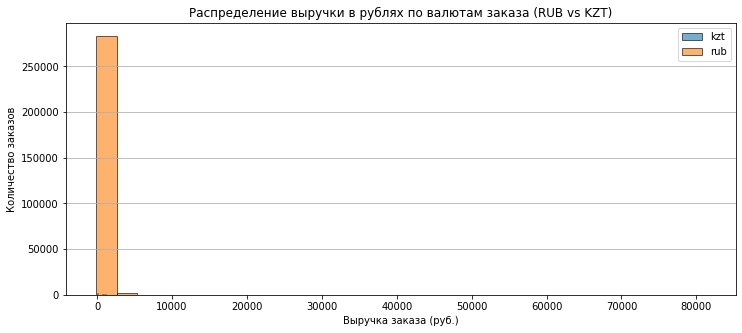

In [23]:
# Построение гистограмм выручки по валютам
df.groupby('currency_code')['revenue_rub'].plot(
    kind='hist',
    bins=30,
    alpha=0.6,  # Прозрачность, чтобы видеть наложение
    edgecolor='black',
    figsize=(12, 5),
    legend=True,
)

# Настройка названий и сетки
plt.title('Распределение выручки в рублях по валютам заказа (RUB vs KZT)')
plt.xlabel('Выручка заказа (руб.)')
plt.ylabel('Количество заказов')
plt.grid(axis='y')

plt.show()

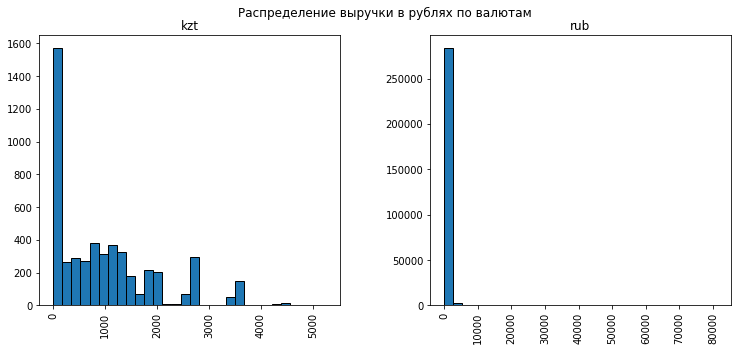

In [24]:
# Построение двух гистограмм в разных окнах
df.hist(
    column='revenue_rub',
    by='currency_code',
    bins=30,
    figsize=(12, 5),
    edgecolor='black',
)

plt.suptitle('Распределение выручки в рублях по валютам')
plt.show()

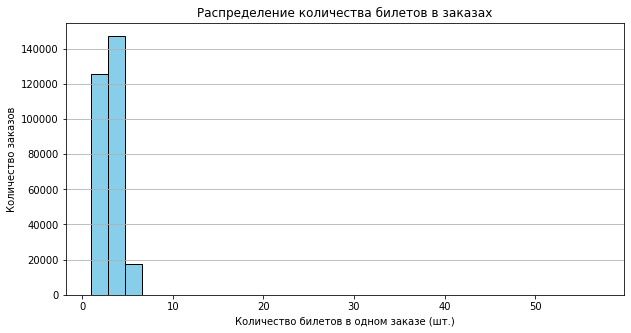

In [25]:
# Построение гистограммы количества билетов
df['tickets_count'].plot(
    kind='hist',
    bins=30,
    color='skyblue',
    edgecolor='black',
    figsize=(10, 5),
)

# Настройка названий и сетки
plt.title('Распределение количества билетов в заказах')
plt.xlabel('Количество билетов в одном заказе (шт.)')
plt.ylabel('Количество заказов')
plt.grid(axis='y')

plt.show()

**Аномалии и фильтрация**

1. **Отрицательная выручка:** минимум −90,76 руб. Вероятно, это возвраты или технические ошибки; оставляем только `revenue_rub > 0`.
2. **Две валюты:** порог по 99-му процентилю считается по выручке, уже пересчитанной в рубли по курсу из таблицы `tenge`, иначе тенге и рубли смешались бы.
3. **Число билетов:** у 75% заказов не больше 4 билетов, максимум — 57. Крупные заказы похожи на оптовые покупки или ошибки, поэтому число билетов тоже ограничено 99-м процентилем.

Фильтрация по 99-му процентилю

In [26]:
# 1. Запоминаем начальное количество строк
initial_count = len(df)

# 2. Удаляем аномальные отрицательные и нулевые значения выручки
df = df[df['revenue_rub'] > 0]

# 3. Рассчитываем 99-й процентиль по выручке в рублях и отсекаем выбросы
revenue_limit_99 = df['revenue_rub'].quantile(0.99)
df = df[df['revenue_rub'] <= revenue_limit_99]

# 4. Рассчитываем 99-й процентиль по количеству билетов и отсекаем выбросы
tickets_limit_99 = df['tickets_count'].quantile(0.99)
df = df[df['tickets_count'] <= tickets_limit_99]

# 5. Выводим итоговый отчёт по отфильтрованным строкам
removed_count = initial_count - len(df)
removed_percent = (removed_count / initial_count) * 100

print(f'Порог 99-го процентиля по выручке: {revenue_limit_99:.2f} руб.')
print(f'Порог 99-го процентиля по кол-ву билетов: {tickets_limit_99:.0f} шт.')
print(
    f'Отфильтровано аномальных заказов (выручка + билеты): {removed_count} ({removed_percent:.2f}%)'
)

Порог 99-го процентиля по выручке: 2628.42 руб.
Порог 99-го процентиля по кол-ву билетов: 6 шт.
Отфильтровано аномальных заказов (выручка + билеты): 9117 (3.13%)


Неявные дубликаты

In [27]:
initial_count = len(df)
duplicates_count = df.duplicated(
    subset=['user_id', 'event_id', 'created_ts_msk']
).sum()

print(f'Найдено неявных дубликатов: {duplicates_count}')

df = df.drop_duplicates(subset=['user_id', 'event_id', 'created_ts_msk'])
print(f'Осталось строк после удаления дубликатов: {len(df)}')

Найдено неявных дубликатов: 111
Осталось строк после удаления дубликатов: 281621


Оптимизация типов данных

In [28]:
# Запоминаем типы данных до оптимизации
dtypes_before = df.dtypes

# Оптимизируем целые числа и числа с плавающей точкой
for col in df.select_dtypes(include=['int64']).columns:
  df[col] = pd.to_numeric(df[col], downcast='integer')

for col in df.select_dtypes(include=['float64']).columns:
  df[col] = pd.to_numeric(df[col], downcast='float')

# Запоминаем типы данных после оптимизации
dtypes_after = df.dtypes

# Формируем и выводим сравнительную таблицу типов данных
types_summary = pd.DataFrame(
    {'Тип до оптимизации': dtypes_before, 'Тип после оптимизации': dtypes_after}
)

display(types_summary)

,Тип до оптимизации,Тип после оптимизации
order_id,int64,int32
user_id,object,object
created_dt_msk,datetime64[ns],datetime64[ns]
created_ts_msk,datetime64[ns],datetime64[ns]
event_id,int64,int32
cinema_circuit,object,object
age_limit,int64,int8
currency_code,object,object
device_type_canonical,object,object
revenue,float64,float32


### Выводы по шагу 2

1. **Даты и объединение:** даты переведены в `datetime64`, заказы объединены с мероприятиями и курсом тенге левым объединением.
2. **Новые показатели:** выручка в тенге пересчитана в рубли по дневному курсу; добавлены `revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`.
3. **Аномалии:** удалены заказы с выручкой ≤ 0 и выше 99-го процентиля (2628,42 руб.), а также с числом билетов больше 6. Всего отфильтровано 9117 заказов (3,13%).
4. **Неявные дубликаты:** удалено 111 заказов с одинаковыми пользователем, мероприятием и временем заказа. Итог — 281 621 строка.
5. **Типы:** числовые столбцы уменьшены до `int8`, `int32`, `float32`.

## Шаг 3. Исследовательский анализ данных

### 3.1. Сезонные изменения в структуре заказов

#### Заказы по месяцам

In [29]:
monthly_orders = df.groupby('month')['order_id'].nunique()
display(monthly_orders)

month
6     32610
7     37896
8     43159
9     68895
10    99061
Name: order_id, dtype: int64

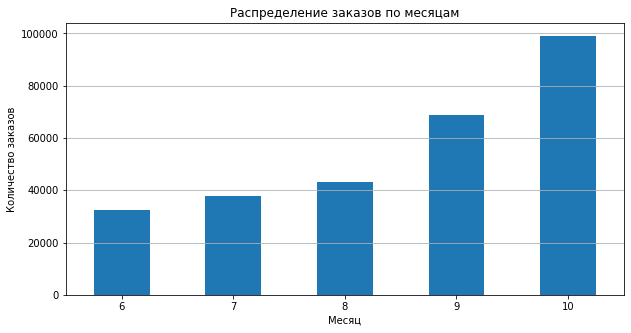

In [30]:
# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
monthly_orders.plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Распределение заказов по месяцам',
               figsize=(10, 5)
)

# Настраиваем оформление графика
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

Число заказов растёт каждый месяц: с 32 610 в июне до 99 061 в октябре, то есть в 3 раза. Самый сильный рост — в сентябре и октябре.

#### Структура заказов летом и осенью (доли, %)

Типы мероприятий:

In [31]:
# 1. Строим сводную таблицу: считаем количество заказов по типам мероприятий и сезонам
pivot_df_event = df.pivot_table(
    index='event_type_main',
    columns='season',
    values='order_id',
    aggfunc='count',
)

# 2. Переводим количество в проценты (делим каждый столбец на его сумму и умножаем на 100)
event_shares = (pivot_df_event / pivot_df_event.sum()) * 100

# 3. Отбираем только лето и осень и переименовываем столбцы
event_shares = event_shares[['лето', 'осень']]
event_shares.columns = ['Доля летом (%)', 'Доля осенью (%)']

# Выводим готовую таблицу
display(event_shares.round(2))

,Доля летом (%),Доля осенью (%)
event_type_main,,
выставки,2.12,1.43
другое,24.99,19.40
концерты,43.79,37.43
спорт,2.43,11.17
стендап,5.58,4.12
театр,20.85,25.44
ёлки,0.24,1.01


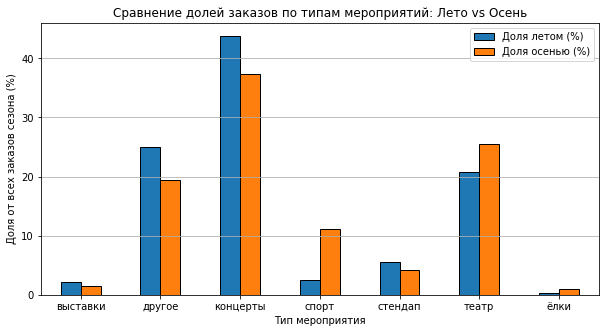

In [32]:
# Строим график
event_shares.plot(kind='bar', figsize=(10, 5), edgecolor='black')

# Добавляем стандартные подписи
plt.title('Сравнение долей заказов по типам мероприятий: Лето vs Осень')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля от всех заказов сезона (%)')
plt.xticks(rotation=0)  # Делаем подписи по оси X
plt.grid(axis='y')  # Добавляем горизонтальную сетку

# Показываем график
plt.show()

Типы устройств:

In [33]:
pivot_df_device = df.pivot_table(
    index='device_type_canonical',
    columns='season',
    values='order_id',
    aggfunc='count',
)

device_shares = (pivot_df_device / pivot_df_device.sum()) * 100

device_shares = device_shares[['лето', 'осень']]
device_shares.columns = ['Доля летом (%)', 'Доля осенью (%)']

display(device_shares.round(2))

,Доля летом (%),Доля осенью (%)
device_type_canonical,,
desktop,19.05,20.38
mobile,80.95,79.62


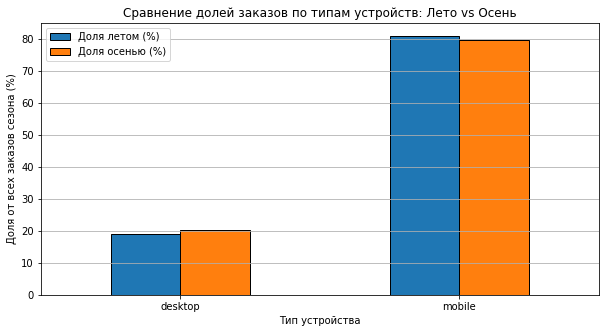

In [34]:
device_shares.plot(kind='bar', figsize=(10, 5), edgecolor='black')

plt.title('Сравнение долей заказов по типам устройств: Лето vs Осень')
plt.xlabel('Тип устройства')
plt.ylabel('Доля от всех заказов сезона (%)')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

Возрастные ограничения:

In [35]:
pivot_df_age = df.pivot_table(
    index='age_limit',
    columns='season',
    values='order_id',
    aggfunc='count',
)

age_limit_shares = (pivot_df_age / pivot_df_age.sum()) * 100

age_limit_shares = age_limit_shares[['лето', 'осень']]
age_limit_shares.columns = ['Доля летом (%)', 'Доля осенью (%)']

display(age_limit_shares.round(2))

,Доля летом (%),Доля осенью (%)
age_limit,,
0,18.16,23.37
6,18.46,17.72
12,21.02,22.17
16,28.49,26.32
18,13.87,10.42


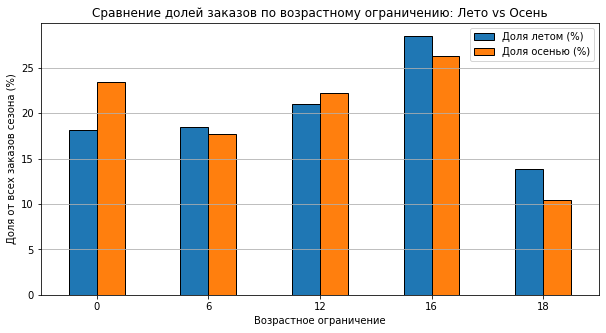

In [36]:
age_limit_shares.plot(kind='bar', figsize=(10, 5), edgecolor='black')

plt.title('Сравнение долей заказов по возрастному ограничению: Лето vs Осень')
plt.xlabel('Возрастное ограничение')
plt.ylabel('Доля от всех заказов сезона (%)')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

#### Средняя выручка с одного билета

In [37]:
pivot_df_one_ticket = df.pivot_table(
    index='event_type_main',
    columns='season',
    values='one_ticket_revenue_rub',
    aggfunc='mean',
)

one_ticket_dynamics = pivot_df_one_ticket[['лето', 'осень']].copy()
one_ticket_dynamics.columns = ['Среднее Летом (руб.)', 'Среднее Осенью (руб.)']

display(one_ticket_dynamics.round(2))

,Среднее Летом (руб.),Среднее Осенью (руб.)
event_type_main,,
выставки,86.709999,91.919998
другое,88.000000,77.360001
концерты,307.109985,269.420013
спорт,55.240002,50.270000
стендап,218.559998,231.470001
театр,216.660004,176.380005
ёлки,271.440002,230.289993


In [38]:
# Вычисляем % Изменения Осени к Лету средней стоимости одного билета
one_ticket_dynamics['Изменение (%)'] = (
    (
        one_ticket_dynamics['Среднее Осенью (руб.)']
        - one_ticket_dynamics['Среднее Летом (руб.)']
    )
    / one_ticket_dynamics['Среднее Летом (руб.)']
    * 100
)

display(one_ticket_dynamics['Изменение (%)'].round(2))

event_type_main
выставки     6.01
другое     -12.08
концерты   -12.27
спорт       -8.99
стендап      5.91
театр      -18.59
ёлки       -15.16
Name: Изменение (%), dtype: float32

In [39]:
# Сортируем динамику,для простоты восприятия от меньшего к большему
one_ticket_dynamics = one_ticket_dynamics.sort_values(by='Изменение (%)')

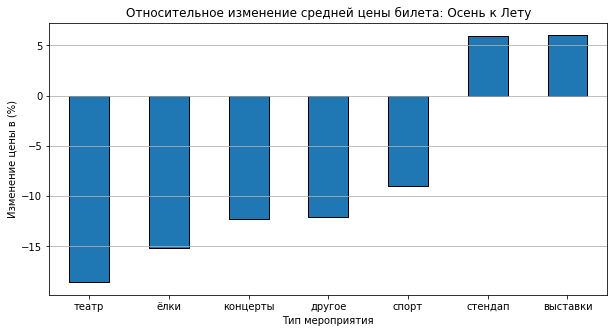

In [40]:
one_ticket_dynamics['Изменение (%)'].plot(kind='bar', figsize=(10, 5), edgecolor='black')

plt.title('Относительное изменение средней цены билета: Осень к Лету')
plt.xlabel('Тип мероприятия')
plt.ylabel('Изменение цены в (%)')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

### Выводы по разделу 3.1

1. **Объём заказов:** с 32 610 в июне до 99 061 в октябре 2024 года — рост в 3 раза.
2. **Структура мероприятий:**
   - доля спорта выросла в 4,6 раза: с 2,43% летом до 11,17% осенью;
   - доля театра выросла с 20,85% до 25,44%;
   - доля концертов снизилась с 43,79% до 37,43%, но это по-прежнему крупнейшая категория.
3. **Устройства и возраст:**
   - доля мобильных заказов почти не изменилась: 80,95% летом и 79,62% осенью;
   - доля мероприятий 0+ выросла с 18,16% до 23,37%, доля 18+ снизилась с 13,87% до 10,42%.
4. **Выручка с одного билета** осенью ниже в большинстве категорий:
   - театр: −18,59% (216,66 → 176,38 руб.);
   - ёлки: −15,16% (271,44 → 230,29 руб.);
   - концерты: −12,27% (307,11 → 269,42 руб.);
   - выросла только у выставок (+6,01%) и стендапа (+5,91%).

Снижение среднего чека осенью объясняется двумя факторами: выручка с билета упала в крупных категориях (театр, концерты), а в структуре выросла доля спорта, где выручка с билета самая низкая (около 50 руб.).

### 3.2. Осенняя активность пользователей

In [41]:
autmn_df = df[df['season'] == 'осень']

In [42]:
daily_activity = autmn_df.groupby('created_dt_msk').agg(
    total_orders = ('order_id', 'count'),
    dau = ('user_id', 'nunique'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
)

In [43]:
daily_activity['orders_per_user'] = daily_activity['total_orders'] / daily_activity['dau']

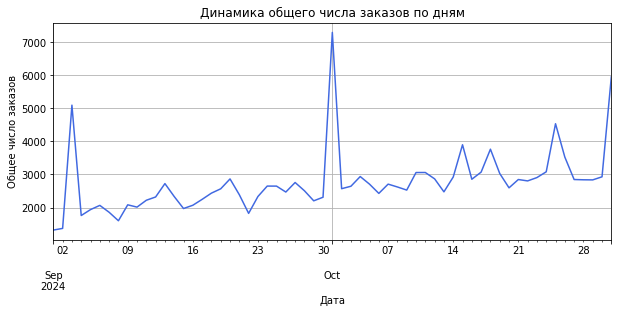

In [44]:
# График визуализации заказов
daily_activity['total_orders'].plot(kind='line',
                   color='royalblue',
                   figsize=(10,4))
plt.title('Динамика общего числа заказов по дням')
plt.xlabel('Дата')
plt.ylabel('Общее число заказов')
plt.grid(True)
plt.show()

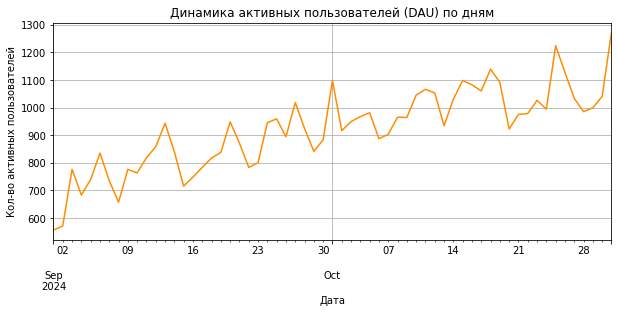

In [45]:
# График визуализации DAU
daily_activity['dau'].plot(kind='line',
                   color='darkorange',
                   figsize=(10,4))
plt.title('Динамика активных пользователей (DAU) по дням')
plt.xlabel('Дата')
plt.ylabel('Кол-во активных пользователей')
plt.grid(True)
plt.show()

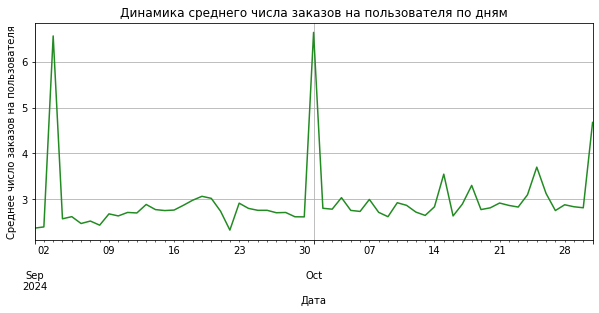

In [46]:
# График визуализации среднего числа заказов на пользователя
daily_activity['orders_per_user'].plot(kind='line',
                   color='forestgreen',
                   figsize=(10,4))
plt.title('Динамика среднего числа заказов на пользователя по дням')
plt.xlabel('Дата')
plt.ylabel('Среднее число заказов на пользователя')
plt.grid(True)
plt.show()

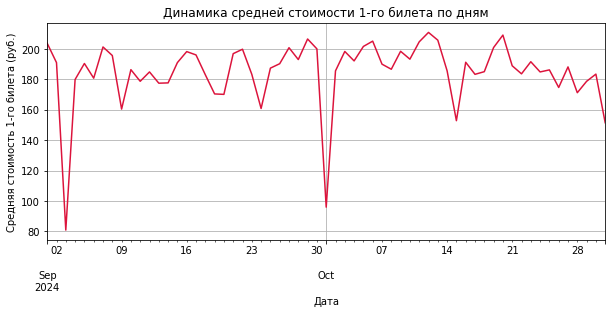

In [47]:
# График визуализации средняя стоимость 1-го билета
daily_activity['avg_ticket_price'].plot(kind='line',
                   color='crimson',
                   figsize=(10,4))
plt.title('Динамика средней стоимости 1-го билета по дням')
plt.xlabel('Дата')
plt.ylabel('Средняя стоимость 1-го билета (руб.)')
plt.grid(True)
plt.show()

In [48]:
# Выделяем осенние данные в отдельную независимую копию, чтобы обойти проблему с предупреждением
autmn_df = df[df['season'] == 'осень'].copy()

# Создаем колонку с днем недели, где 1 - понедельник, а 7 - воскресенье (+1)
autmn_df['day_of_week'] = autmn_df['created_dt_msk'].dt.dayofweek+1

In [49]:
# Заполняем по умолчанию все строки значением 'выходные'
autmn_df['day_type'] = "выходные"

# Перезаписываем в 'будни' только те строки, где день недели меньше 5
autmn_df.loc[autmn_df['day_of_week'] <= 5, 'day_type'] = "будни"

In [50]:
# Группируем по дням и типу дня, агрегируем показатели
daily_activity = autmn_df.groupby(['created_dt_msk', 'day_type']).agg(
        orders_count=('order_id', 'count'),
        dau=('user_id', 'nunique'),
        avg_ticket_price=('one_ticket_revenue_rub','mean')
    ).reset_index()

# Считаем среднее количество заказов на одного активного пользователя за этот день
daily_activity['orders_per_user'] = (daily_activity['orders_count'] / daily_activity['dau'])

In [51]:
# Группируем по типу дня и считаем среднее
weekly_comparison = daily_activity.groupby('day_type')[['orders_count', 'dau', 'orders_per_user', 'avg_ticket_price']].mean()

# Округляем до 2 знаков после запятой и выводим
display(weekly_comparison.round(2))

,orders_count,dau,orders_per_user,avg_ticket_price
day_type,,,,
будни,2897.86,935.66,3.06,179.839996
выходные,2379.41,879.41,2.68,197.720001


### Выводы по разделу 3.2

1. **Динамика по дням (сентябрь–октябрь):**
   - DAU растёт в течение осени примерно с 560 до 1250 пользователей в день, с недельными колебаниями; число заказов тоже растёт;
   - в большинство дней на одного активного пользователя приходится 2,5–3,1 заказа;
   - 3 сентября и 1 октября видны всплески: до ~5 тыс. и ~7,3 тыс. заказов, до ~6,6 заказа на пользователя, при этом выручка с билета падает до ~80–95 руб. Похоже на массовые покупки дешёвых билетов; причину по этим данным установить нельзя.
2. **Будни и выходные:**
   - в будни в среднем 2897,86 заказа в день при DAU 935,66 и 3,06 заказа на пользователя;
   - в выходные — 2379,41 заказа при DAU 879,41 и 2,68 заказа на пользователя;
   - средняя выручка с билета в выходные выше: 197,72 руб. против 179,84 руб. в будни.

### 3.3. Популярные регионы и партнёры

In [52]:
# Группируем число мероприятий и кол-во заказов по регионам
region_stats = df.groupby('region_name').agg(
    total_events = ('event_id', 'nunique'),
    total_orders = ('order_id', 'count'))

In [53]:
# Общее число заказов
sum_orders = df['order_id'].count()

In [54]:
# Общее число уникальных мероприятий
sum_total_events = df['event_id'].nunique()

In [55]:
# Доля уникальных мероприятий региона от общего числа
region_stats['share_events'] = (region_stats['total_events'] / sum_total_events)

In [56]:
# Доля заказов региона от общего числа заказов
region_stats['share_orders'] = (region_stats['total_orders'] / sum_orders)

In [57]:
# Выводим ТОП-5 активных регионов по кол-ву заказов и сортируем их по убыванию
region_stats.sort_values(by='total_orders', ascending=False).round(4).head(5)

,total_events,total_orders,share_events,share_orders
region_name,,,,
Каменевский регион,5797,85441,0.2633,0.3034
Североярская область,3774,43475,0.1714,0.1544
Широковская область,1217,16083,0.0553,0.0571
Медовская область,462,13576,0.0210,0.0482
Озернинский край,349,10402,0.0159,0.0369


In [58]:
# Выводим общий список регионов по кол-ву заказов и сортируем их по убыванию
region_stats.sort_values(by='total_orders', ascending=False).round(4)

,total_events,total_orders,share_events,share_orders
region_name,,,,
Каменевский регион,5797,85441,0.2633,0.3034
Североярская область,3774,43475,0.1714,0.1544
Широковская область,1217,16083,0.0553,0.0571
Медовская область,462,13576,0.0210,0.0482
Озернинский край,349,10402,0.0159,0.0369
...,...,...,...,...
Лесноярский край,2,19,0.0001,0.0001
Крутоводский регион,7,18,0.0003,0.0001
Верхозёрский край,2,11,0.0001,0.0000


In [59]:
# Группируем число мероприятий, кол-во заказов и общую выручку по билетным партнерам
partner_stats = df.groupby('service_name').agg(
    total_events = ('event_id', 'nunique'),
    total_orders = ('order_id', 'count'),
    sum_revenue = ('revenue_rub', 'sum'))

In [60]:
# Общая сумма выручки
total_revenue = df['revenue_rub'].sum()

In [61]:
# Доля заказов билетного партнера от общего числа заказов
partner_stats['share_orders'] = partner_stats['total_orders'] / sum_orders

In [62]:
# Доля выручки билетного партнера от общей суммы выручки
partner_stats['share_revenue'] = partner_stats['sum_revenue'] / total_revenue

In [63]:
# Выводим ТОП-5 активных билетных партнеров по сумме выручки и сортируем их по убыванию
partner_stats.sort_values(by='sum_revenue', ascending=False).round(4).head(5)

,total_events,total_orders,sum_revenue,share_orders,share_revenue
service_name,,,,,
Билеты без проблем,4016,57918,24721430.0,0.2057,0.1660
Мой билет,1295,34097,21033630.0,0.1211,0.1413
Облачко,2335,26408,18606756.0,0.0938,0.1250
Лови билет!,4818,40511,16724555.0,0.1438,0.1123
Весь в билетах,856,16434,16563546.0,0.0584,0.1113


In [64]:
# Выводим общий список билетных партнеров по сумме выручки и сортируем их по убыванию
partner_stats.sort_values(by='sum_revenue', ascending=False).round(4)

,total_events,total_orders,sum_revenue,share_orders,share_revenue
service_name,,,,,
Билеты без проблем,4016,57918,2.472143e+07,0.2057,0.1660
Мой билет,1295,34097,2.103363e+07,0.1211,0.1413
Облачко,2335,26408,1.860676e+07,0.0938,0.1250
Лови билет!,4818,40511,1.672456e+07,0.1438,0.1123
Весь в билетах,856,16434,1.656355e+07,0.0584,0.1113
Билеты в руки,3492,39803,1.319994e+07,0.1413,0.0887
Край билетов,252,6117,6.426961e+06,0.0217,0.0432
Прачечная,1026,10220,4.746164e+06,0.0363,0.0319
Дом культуры,272,4428,4.400412e+06,0.0157,0.0296


### Выводы по разделу 3.3

1. **Регионы:**
   - Каменевский регион — 30,34% заказов (85 441) и 26,33% уникальных мероприятий (5797);
   - Североярская область — 15,44% заказов (43 475) и 17,14% мероприятий (3774);
   - вместе они дают 45,78% заказов; у каждого из остальных 79 регионов меньше 5,7%.

2. **Билетные партнёры:**
   - «Билеты без проблем» — больше всего заказов (20,57%, 57 918) и выручки (16,60%, 24,72 млн руб.);
   - «Лови билет!» — больше всего уникальных мероприятий (4818), второе место по заказам (14,38%) и 11,23% выручки;
   - «Мой билет» — второе место по выручке (14,13%, 21,03 млн руб.) при 12,11% заказов, то есть высокая выручка на заказ;
   - «Облачко» — третье место по выручке (12,50%, 18,61 млн руб.) и 9,38% заказов;
   - четыре партнёра вместе дают около 54% выручки и 56% заказов.

## Шаг 4. Статистический анализ

### Метод

Проверяем две гипотезы об активности пользователей мобильных и десктопных устройств на данных за осень (`season == 'осень'`).

- Используется двухвыборочный t-тест Уэлча (`scipy.stats.ttest_ind`, `equal_var=False`), односторонний.
- Выборки большие (тысячи пользователей и десятки тысяч заказов), поэтому t-тест применим к средним даже при скошенных распределениях.
- Уровень значимости $\alpha = 0.05$.

**Ограничение:** пользователь, заказывавший и с телефона, и с компьютера, попадает в обе группы, поэтому выборки не полностью независимы.

### Данные за осень

In [65]:
# Оставляем только заказы за осень
autumn_df = df[df['season'] == 'осень']

# Посмотрим распределение количества заказов по типам устройств
print('Количество заказов осенью по устройствам:')
print(autumn_df.groupby('device_type_canonical')['order_id'].count())

Количество заказов осенью по устройствам:
device_type_canonical
desktop     34234
mobile     133722
Name: order_id, dtype: int64


### Гипотеза 1

#### Число заказов на одного пользователя

* $H_0$: среднее число заказов на пользователя на мобильных устройствах равно среднему на десктопе.
* $H_1$: на мобильных устройствах среднее число заказов на пользователя больше.

In [66]:
# 1. Считаем количество заказов для каждого пользователя и типа устройства
user_orders = (
    autumn_df.groupby(['user_id', 'device_type_canonical'])['order_id']
    .count()
    .reset_index()
)

# 2. Разделяем пользователей на две группы
mobile_user_orders = user_orders[
    user_orders['device_type_canonical'] == 'mobile'
]['order_id']
desktop_user_orders = user_orders[
    user_orders['device_type_canonical'] == 'desktop'
]['order_id']

# 3. Выводим средние значения
print(
    f'Среднее кол-во заказов на мобильных: {mobile_user_orders.mean():.2f}'
)
print(
    f'Среднее кол-во заказов на десктопе: {desktop_user_orders.mean():.2f}'
)

# 4. Проводим t-тест (односторонний: alternative='greater')
alpha = 0.05
results_1 = stats.ttest_ind(
    mobile_user_orders,
    desktop_user_orders,
    equal_var=False,
    alternative='greater',
)

print(f'p-value: {results_1.pvalue}')

# 5. Сравниваем p-value с alpha
if results_1.pvalue < alpha:
    print(
        'Отвергаем H0: пользователи мобильного приложения делают в среднем больше заказов.'
    )
else:
    print(
        'Не получилось отвергнуть H0: значимой разницы в количестве заказов нет.'
    )

Среднее кол-во заказов на мобильных: 9.48
Среднее кол-во заказов на десктопе: 7.04
p-value: 0.0007506419953664927
Отвергаем H0: пользователи мобильного приложения делают в среднем больше заказов.


### Гипотеза 2: среднее время между заказами (`days_since_prev`)

Первые покупки (`days_since_prev` пустой) исключены. Наблюдение — отдельный повторный заказ.

* $H_0$: среднее время между заказами на мобильных устройствах равно среднему на десктопе.
* $H_1$: на мобильных устройствах среднее время между заказами больше.

In [67]:
# 1. Удаляем пропуски (первые покупки), оставляем только повторные заказы
repeat_orders = autumn_df.dropna(subset=['days_since_prev'])

# 2. Разделяем время между заказами на две группы
mobile_days = repeat_orders[repeat_orders['device_type_canonical'] == 'mobile'][
    'days_since_prev'
]
desktop_days = repeat_orders[
    repeat_orders['device_type_canonical'] == 'desktop'
]['days_since_prev']

# 3. Выводим среднее время между заказами в днях
print(
    f'Среднее время между заказами на мобильных: {mobile_days.mean():.2f} дней'
)
print(
    f'Среднее время между заказами на десктопе: {desktop_days.mean():.2f} дней'
)

# 4. Проводим t-тест (односторонний: alternative='greater')
alpha = 0.05
results_2 = stats.ttest_ind(
    mobile_days, 
    desktop_days, 
    equal_var=False, 
    alternative='greater'
)

print(f'p-value: {results_2.pvalue}')

# 5. Сравниваем p-value с alpha
if results_2.pvalue < alpha:
    print(
        'Отвергаем H0: время между заказами у мобильных пользователей в среднем выше.'
    )
else:
    print(
        'Не получилось отвергнуть H0: значимой разницы во времени между заказами нет.'
    )

Среднее время между заказами на мобильных: 3.77 дней
Среднее время между заказами на десктопе: 3.03 дней
p-value: 3.0106813854361693e-22
Отвергаем H0: время между заказами у мобильных пользователей в среднем выше.


### Выводы по шагу 4

1. **Гипотеза 1 (заказы на пользователя):** в среднем 9,48 заказа на мобильных и 7,04 на десктопе; p-value = 0,00075 < 0,05, $H_0$ отвергается. Пользователи мобильных устройств делают в среднем на 2,44 заказа больше.
2. **Гипотеза 2 (время между заказами):** 3,77 дня на мобильных и 3,03 дня на десктопе; p-value = 3,01e-22 < 0,05, $H_0$ отвергается. Интервал между заказами на мобильных в среднем на 0,74 дня больше.

Мобильные пользователи делают больше заказов за осень, но повторные заказы у них идут с чуть большими интервалами.

## Шаг 5. Общий вывод и рекомендации

### Данные

Заказы, мероприятия и курс тенге за июнь–октябрь 2024 года. После пересчёта тенге в рубли, удаления отрицательной выручки, фильтрации по 99-му процентилю выручки и числа билетов и удаления неявных дубликатов осталось 281 621 заказ.

### Результаты исследовательского анализа

- **Сезонность:** заказов в октябре в 3 раза больше, чем в июне (99 061 против 32 610).
- **Структура:** осенью крупнейшие категории — концерты (37,43% заказов) и театр (25,44%); доля спорта выросла с 2,43% до 11,17%, доля мероприятий 0+ — с 18,16% до 23,37%.
- **Средний чек:** выручка с билета осенью ниже в театре (−18,59%), на ёлках (−15,16%) и концертах (−12,27%); дополнительно вырос вес дешёвого спорта.
- **Активность осенью:** DAU растёт; в будни больше заказов (2897,86 в день) и заказов на пользователя (3,06), чем в выходные (2379,41 и 2,68), но выручка с билета выше в выходные (197,72 руб. против 179,84 руб.).
- **Регионы:** Каменевский регион (30,34% заказов) и Североярская область (15,44%) вместе дают 45,78% заказов.
- **Партнёры:** «Билеты без проблем», «Мой билет», «Облачко» и «Лови билет!» дают около 54% выручки и 56% заказов.

### Гипотезы (осень)

- Пользователи мобильных устройств делают больше заказов: 9,48 против 7,04, p-value = 0,00075, $H_0$ отвергнута.
- Время между заказами на мобильных больше: 3,77 против 3,03 дня, p-value = 3,01e-22, $H_0$ отвергнута.

---

## Рекомендации для продуктовой команды

1. **Мобильный канал:** на мобильные устройства приходится 80% заказов, а мобильные пользователи делают больше заказов, поэтому новые функции и акции в первую очередь стоит запускать в приложении. Более длинные интервалы между заказами — повод тестировать напоминания и персональные подборки.
2. **Средний чек:** разобраться, почему упала выручка с билета в театре и на концертах (цены, скидки, комиссия), и проверить пакетные предложения и кросс-продажи.
3. **Партнёры:** четыре крупнейших оператора дают больше половины выручки; условия работы с ними критичны, но и зависимость от них высока.
4. **Регионы:** почти половина заказов приходится на два региона; рост в остальных регионах снизит эту зависимость.